--- ANTRENARE ONE-CLASS SVM PE DATELE eBPF ---
Date partajate cu succes: Train_Normal=25980, Test_Total=13559
Antrenare One-Class SVM în curs...
Timp antrenare: 0.91s

Raport clasificare:
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     11161
        Atac       0.82      0.98      0.89      2398

    accuracy                           0.96     13559
   macro avg       0.91      0.96      0.93     13559
weighted avg       0.96      0.96      0.96     13559

AUC: 0.9796


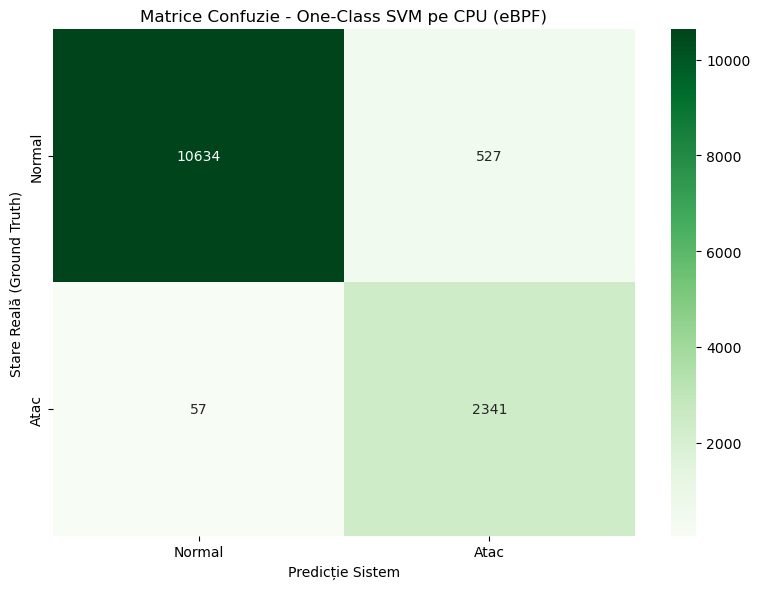

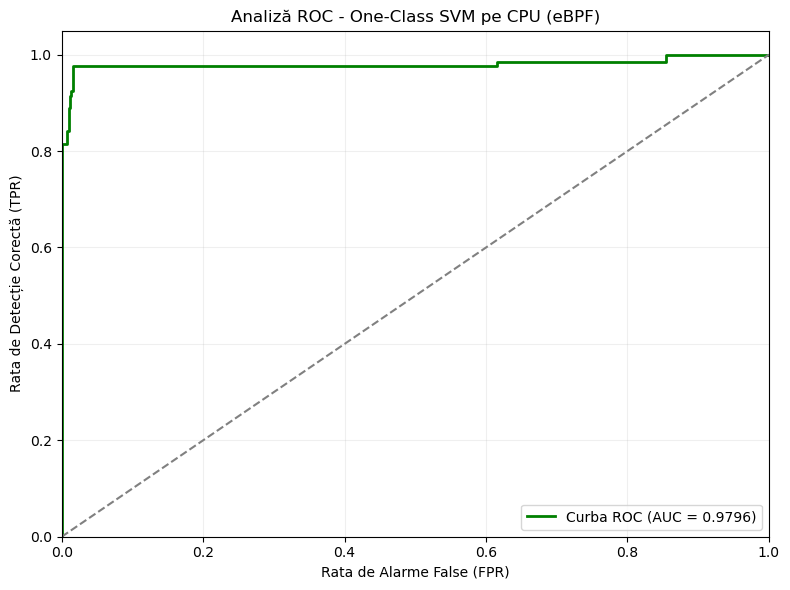


Toate rezultatele au fost salvate cu succes în: D:\disertatie\eBPF_WSL\rezultate_eBPF\One_Class_SVM


In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

dataset_path = 'dataset_eBPF.csv'
rezultate_path = r'D:\disertatie\eBPF_WSL\rezultate_eBPF\One_Class_SVM'
os.makedirs(rezultate_path, exist_ok=True)

print("--- ANTRENARE ONE-CLASS SVM PE DATELE eBPF ---")
df = pd.read_csv(dataset_path)
X_raw = df[['pid', 'uid', 'gid', 'len', 'hour']].values
y = df['label'].values

rng = np.random.default_rng(42)
X_clean = X_raw + rng.normal(0, 1e-5, size=X_raw.shape)

indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(len(df) * 0.7)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X_clean[train_indices][y[train_indices] == 0]
X_test = X_clean[test_indices]
y_test = y[test_indices]

print(f"Date partajate cu succes: Train_Normal={len(X_train)}, Test_Total={len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05, cache_size=2000)

start_time = time.time()
print("Antrenare One-Class SVM în curs...")
model.fit(X_train_scaled)
train_time = time.time() - start_time

decision_scores = model.decision_function(X_test_scaled)
y_pred_raw = model.predict(X_test_scaled)
y_pred = np.where(y_pred_raw == -1, 1, 0)

cm = confusion_matrix(y_test, y_pred)

y_scores = -decision_scores
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Atac'])
print(f"Timp antrenare: {train_time:.2f}s")
print("\nRaport clasificare:")
print(report)
print(f"AUC: {roc_auc:.4f}")

full_report_text = f"AUC: {roc_auc:.4f}\nTimp Antrenare: {train_time:.2f}s\n\nMatrice Confuzie:\n{cm}\n\n{report}"
with open(os.path.join(rezultate_path, 'raport_ebpf_ocsvm_cpu.txt'), 'w') as f:
    f.write(full_report_text)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Atac'], yticklabels=['Normal', 'Atac'])
plt.title('Matrice Confuzie - One-Class SVM pe CPU (eBPF)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ebpf_ocsvm_cpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('Rata de Detecție Corectă (TPR)')
plt.xlabel('Rata de Alarme False (FPR)')
plt.title('Analiză ROC - One-Class SVM pe CPU (eBPF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ebpf_ocsvm_cpu.png'), dpi=300)
plt.show()

print(f"\nToate rezultatele au fost salvate cu succes în: {rezultate_path}")